<h1>Задание 4</h1>
<b>Реализовать алгоритм Дейкстры </b> и найти время в пути от станции метро 
Маяковская до всех остальных станций. Время перехода между 
пересадочными станциями принять равным 2 мин. Время в пути между 
станциями определить по графику движения поездов (можно ориентироваться 
на время отправления первого или последнего поезда). 

<h3>Распаковываем csv файл</h3>

In [135]:
import pandas as pd

def convert(s):
    return s.replace("\\","/")

link = convert(r'C:\Users\User\Desktop\metro2.csv')
df = pd.read_csv(link2, header=0)
df.head(5)

,from,to,time
0,Девяткино,ГражданскийПроспект,4
1,ГражданскийПроспект,Академическая,4
2,Академическая,Политехническая,2
3,Политехническая,ПлощадьМужества,2
4,ПлощадьМужества,Лесная,3


<h3>Реализация алгоритма Дейкстры</h3>

Здесь пользуемся библиотекой <b>heapq<b>

In [120]:
import heapq

def deikstra(graph, start):
    distances = {vertex: float('infinity') for vertex in graph}
    distances[start] = 0
    queue = [(0, start)]

    while queue:
        current_distance, current_vertex = heapq.heappop(queue)

        # Обрабатываем только вершину с наименьшим расстоянием
        if current_distance > distances[current_vertex]:
            continue

        for neighbor, weight in graph[current_vertex].items():
            distance = current_distance + weight

            # Рассматриваем этот новый путь только в том случае, если он лучше любого пути, который мы нашли до сих пор
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(queue, (distance, neighbor))

    return distances

<h3>Приводим граф к нужному виду</h3>
<b>Вид:</b> 

Граф - это словарь в котором ключи это вершины откуда, <br>значения это словари 
у которых ключи это вершины докуда и вес

In [123]:
import numpy as np

graph = dict()
# Граф - это словарь в котором ключи это вершины откуда, а значения это словари 
# у которых ключи это вершины докуда и вес

metro_numpy = df.values
for val in metro_numpy:
    fr, to, w = val
    if fr not in graph:
        graph[fr] = dict()
    if to not in graph[fr]:
        graph[fr][to] = w

    if to not in graph:
        graph[to] = dict()
    if fr not in graph[fr]:
        graph[to][fr] = w
#Если нужно посмотреть граф:
#print(graph)

<h3>Пользуемся алгоритмом</h3>
Получаем результат в виде словаря <b>dist</b> <br>
Для того, чтобы получить весь список нужно менять переменную <b>first_n_el</b>

In [126]:
dist = deikstra(graph, 'Маяковская')

def pr_str(fr, to, time):
    return 'От {} до {} путь занимает {} минут'.format(fr,to,time)

first_n_el = 10
for i, (k, v) in enumerate(dist.items()):
    if i == first_n_el:
        break
    print(pr_str('Маяковская', k,v))
    

От Маяковская до Девяткино путь занимает 27 минут
От Маяковская до ГражданскийПроспект путь занимает 23 минут
От Маяковская до Академическая путь занимает 19 минут
От Маяковская до Политехническая путь занимает 17 минут
От Маяковская до ПлощадьМужества путь занимает 15 минут
От Маяковская до Лесная путь занимает 12 минут
От Маяковская до Выборгская путь занимает 10 минут
От Маяковская до ПлощадьЛенина путь занимает 7 минут
От Маяковская до Чернышевская путь занимает 5 минут
От Маяковская до ПлощадьВосстания путь занимает 2 минут


<h3>Изобразим наш граф</h3>
Для этого нужно выделить вершины и список всех ребер

In [129]:
fr = df['from'].values
to = df['to'].values
nodes = set()
for el in range(len(df)):
    nodes.add(fr[el])
    nodes.add(b[el])
    
len(nodes)

73

In [131]:
from_and_to = df.drop(columns = ['time']).values
edges = []
for i in range(len(aba)):
    edges.append((from_and_to[i][0], from_and_to[i][1]))
edges[:5]

[('Девяткино', 'ГражданскийПроспект'),
 ('ГражданскийПроспект', 'Академическая'),
 ('Академическая', 'Политехническая'),
 ('Политехническая', 'ПлощадьМужества'),
 ('ПлощадьМужества', 'Лесная')]

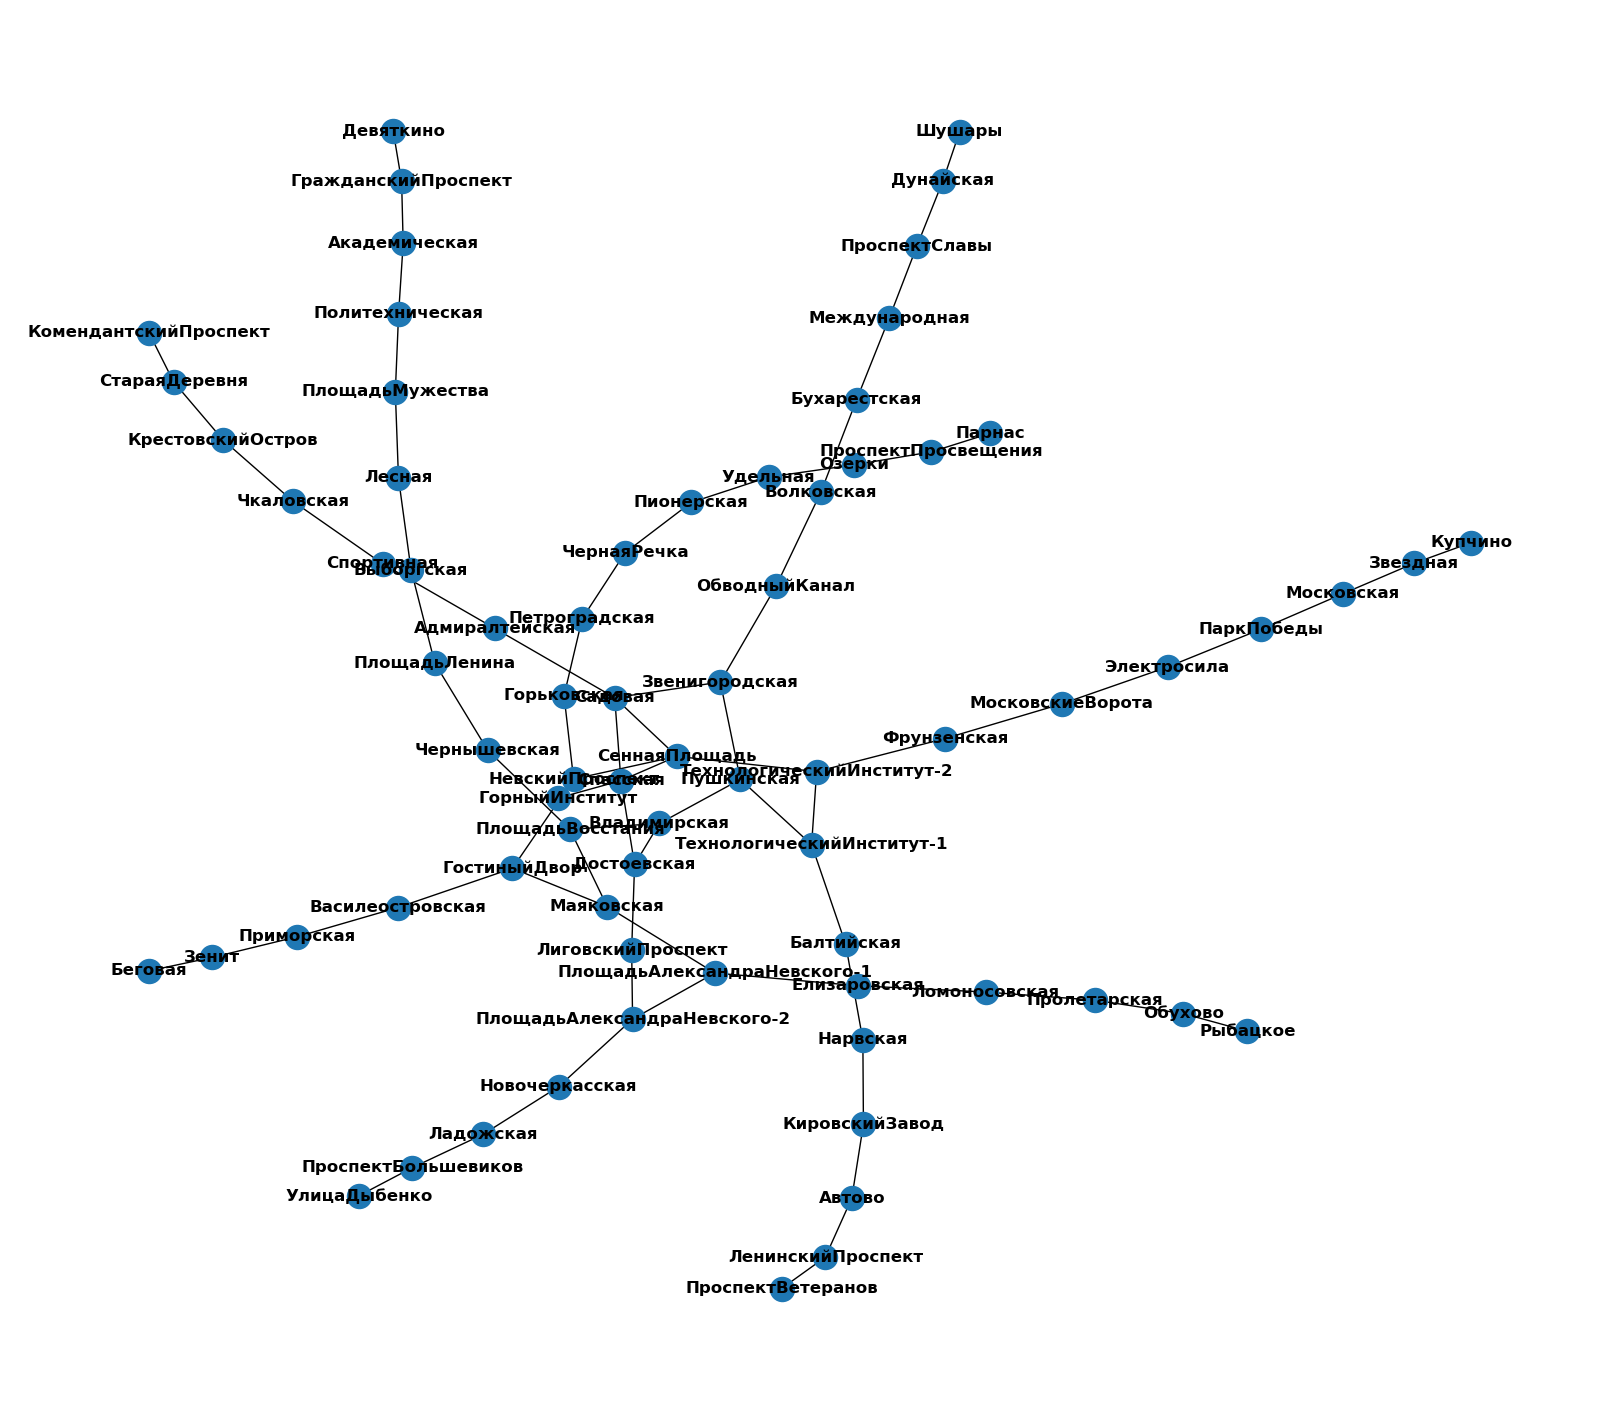

In [137]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize = (16,14))
nx.draw(G, with_labels = True, font_weight = 'bold')
plt.show()